In [73]:
import pandas as pd
import numpy as np
import torch
from environments.WMS_policies import Predictor

data = pd.read_csv("environments/Data/WMS/extracted_data.csv")
et_data = data["ET_0"]

# normalize the dataset and stores the mean and std

mean = et_data.mean()
std = et_data.std()

et_data = (et_data - mean) / std
et_data = torch.Tensor(et_data.values)

# split data in training and validation sets

train_data = et_data[:int(len(et_data) * 0.8)]
val_data = et_data[int(len(et_data) * 0.8):]

# create the dataloaders
from torch.utils.data import Dataset, DataLoader

class ETDataset(Dataset):
    def __init__(self, data, seq_length, device='cuda'):
        self.data = data
        self.seq_length = seq_length
        self.device = device

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, index):
        x = self.data[index:index + self.seq_length].to(self.device)
        y = self.data[index+1:index+self.seq_length+1].to(self.device)
        return x, y

seq_length = 7

In [48]:
# create a training loop with decaying learning rate
best_val_loss = float('inf')
best_model_state = None

mdl = Predictor(n_features=1, n_hidden=20, n_layers=2, mean=mean, std=std, device="cuda")
optimizer = torch.optim.Adam(mdl.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.9)
criterion = torch.nn.HuberLoss()
num_epochs = 1000
batch_size = 512

dataset = ETDataset(et_data, seq_length, device="cuda")
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

val_dataset = ETDataset(val_data, seq_length, device="cuda")
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Training loop

for epoch in range(num_epochs):
    mdl.train()
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.unsqueeze(1)  # Add feature dimension
        y_batch = y_batch.unsqueeze(1)  # Add feature dimension

        optimizer.zero_grad()
        outputs = mdl(x_batch)
        loss = criterion(outputs, y_batch)

        epoch_loss += loss

    epoch_loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss / len(dataloader)}")
    if epoch % 10 == 0:
        mdl.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_dataloader:
                x_batch = x_batch.unsqueeze(1)
                y_batch = y_batch.unsqueeze(1)
                outputs = mdl(x_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(mdl, "predictive_models/et_model_2.pth")
                best_model_state = mdl.state_dict()
        print(f"Validation Loss: {val_loss / len(val_dataloader)}")


Epoch 1/1000, Loss: 0.5419222116470337
Validation Loss: 0.5201539099216461
Epoch 2/1000, Loss: 0.5206937193870544
Epoch 3/1000, Loss: 0.5019910931587219
Epoch 4/1000, Loss: 0.48456794023513794
Epoch 5/1000, Loss: 0.46800342202186584
Epoch 6/1000, Loss: 0.4511578679084778
Epoch 7/1000, Loss: 0.4341457486152649
Epoch 8/1000, Loss: 0.4162055253982544
Epoch 9/1000, Loss: 0.3966464698314667
Epoch 10/1000, Loss: 0.37522783875465393
Epoch 11/1000, Loss: 0.3509465456008911
Validation Loss: 0.32509645819664
Epoch 12/1000, Loss: 0.32315173745155334
Epoch 13/1000, Loss: 0.2917172908782959
Epoch 14/1000, Loss: 0.2570628225803375
Epoch 15/1000, Loss: 0.22064615786075592
Epoch 16/1000, Loss: 0.1854790896177292
Epoch 17/1000, Loss: 0.1559208482503891
Epoch 18/1000, Loss: 0.1369374841451645
Epoch 19/1000, Loss: 0.13209372758865356
Epoch 20/1000, Loss: 0.13954868912696838
Epoch 21/1000, Loss: 0.15055282413959503
Validation Loss: 0.1616069252292315
Epoch 22/1000, Loss: 0.15661461651325226
Epoch 23/1000,

KeyboardInterrupt: 

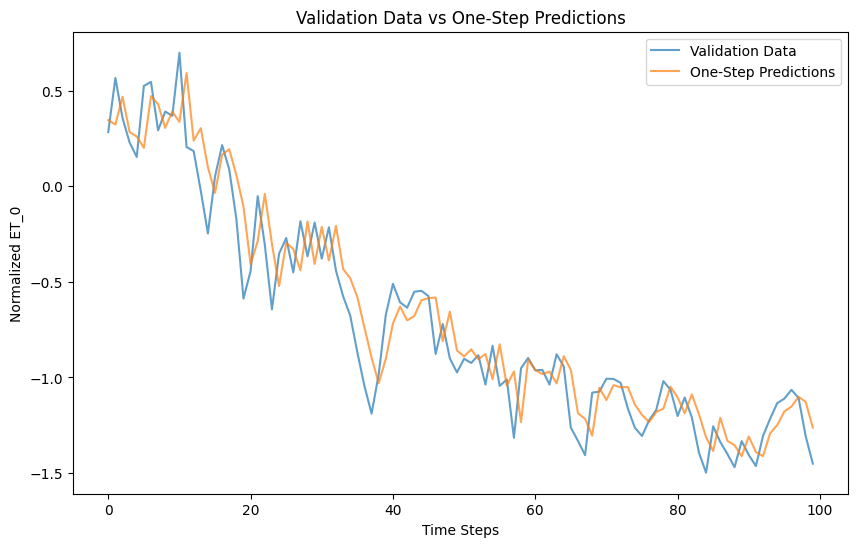

In [44]:
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
mdl.eval()

# Generate predictions for the validation data

real_values = []
predictions = []
for i in range(100):
    x = val_data[i:i + seq_length].unsqueeze(0).to("cuda")
    y = val_data[i + seq_length].cpu().numpy().item()
    real_values.append(y)
    y_pred = mdl.predict(x, n_steps=1, isNormalized=True).cpu().numpy().item()
    predictions.append(y_pred)  


# Flatten the lists
val_predictions = np.array(predictions)
val_targets = np.array(real_values)

# Plot the validation data vs predictions
plt.figure(figsize=(10, 6))
plt.plot(val_targets, label="Validation Data", alpha=0.7)
plt.plot(val_predictions, label="One-Step Predictions", alpha=0.7)
plt.legend()
plt.xlabel("Time Steps")
plt.ylabel("Normalized ET_0")
plt.title("Validation Data vs One-Step Predictions")
plt.show()

In [26]:
i = 0
pred_steps = 7
x = val_data[i:i + seq_length].unsqueeze(0).to("cuda")
real_values = val_data[i + seq_length:i + seq_length + pred_steps].cpu().numpy().flatten()

y_pred = mdl.predict(x, n_steps=pred_steps).cpu().numpy().flatten()


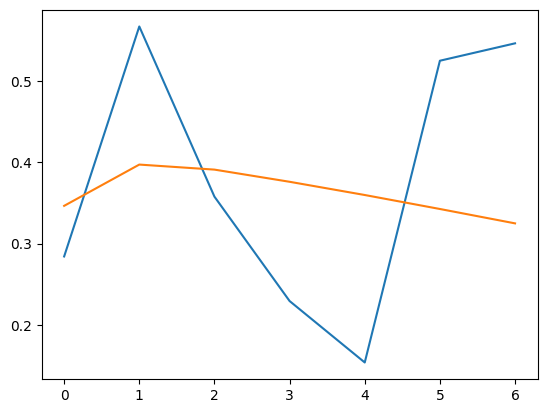

In [27]:
plt.plot(real_values, label="Validation Data")
plt.plot(y_pred)

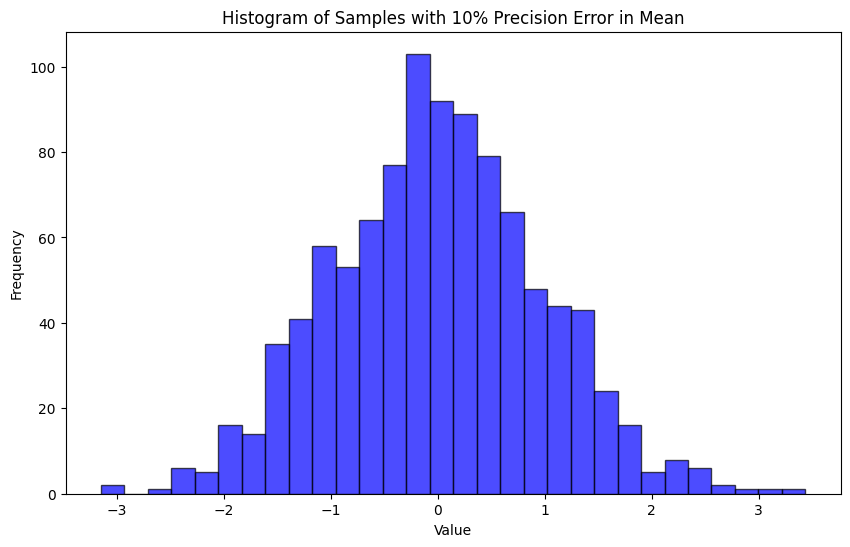

In [58]:
# Generate samples from a normal distribution with a mean affected by 10% precision error
true_mean = 0
std_dev = 1
num_samples = 1000

# Add a 10% precision error to the mean
precision_error = np.random.normal(loc=0, scale=0.1 * abs(true_mean), size=num_samples)
adjusted_means = true_mean + precision_error

# Sample from the normal distribution with adjusted means
samples = np.random.normal(loc=adjusted_means, scale=std_dev)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title("Histogram of Samples with 10% Precision Error in Mean")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

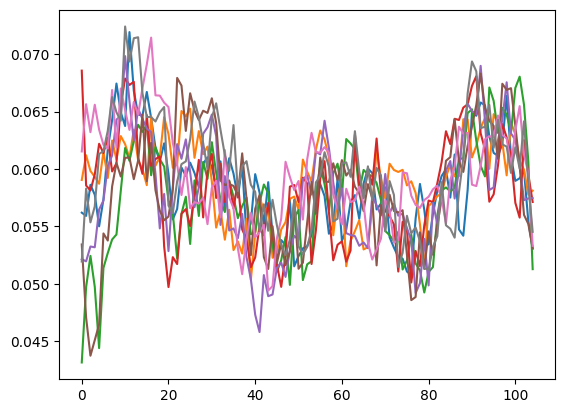

In [72]:
import matplotlib.pyplot as plt
import numpy as np

path = "logs/wms/mpc/"
relative_yields = np.zeros(8)
water_usages = np.zeros(8)

for i in range(8):
    data = np.load(path + str(i) + "/mpc_data.npz")
    relative_yields[i] = data["relative_yield"]
    water_usages[i] = data["water_usage"]
    plt.plot(np.convolve(data["actions"], np.ones(10), mode='valid'), label=str(i))



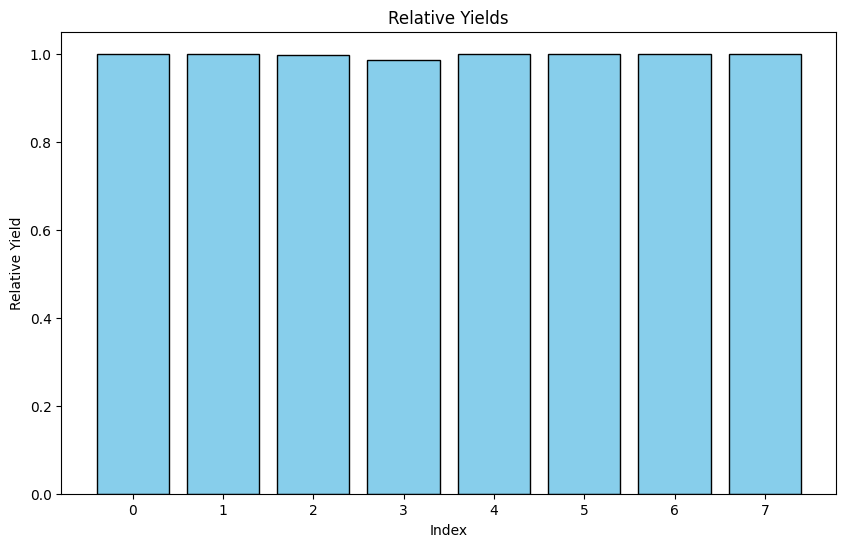

In [74]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(relative_yields)), relative_yields, color='skyblue', edgecolor='black')
plt.xlabel("Index")
plt.ylabel("Relative Yield")
plt.title("Relative Yields")
plt.show()

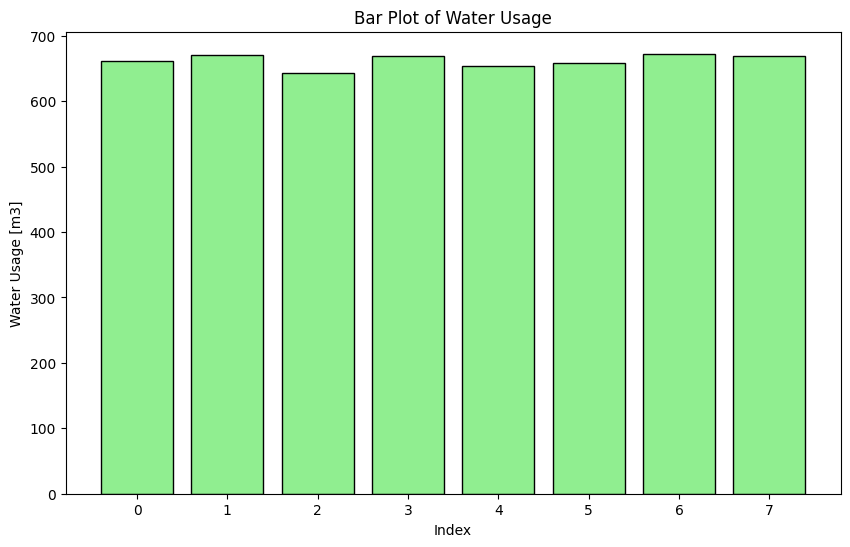

In [79]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(water_usages)), water_usages*1000, color='lightgreen', edgecolor='black')
plt.xlabel("Index")
plt.ylabel("Water Usage [m3]")
plt.title("Bar Plot of Water Usage")
plt.show()

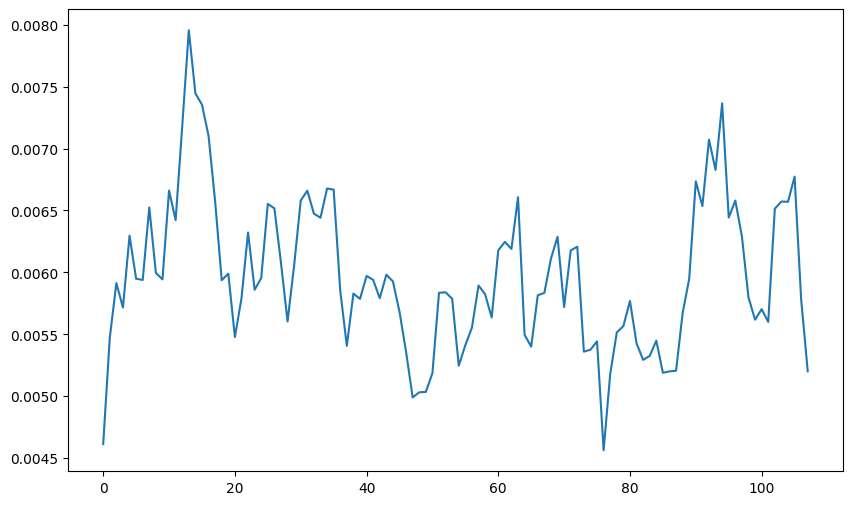

In [68]:
y = np.convolve(data["actions"], np.ones(7)/7, mode='valid')
plt.figure(figsize=(10, 6))
plt.plot(y)